In [18]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import re, csv, torch
warnings.filterwarnings("ignore")

linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

88 88 88 88 69867


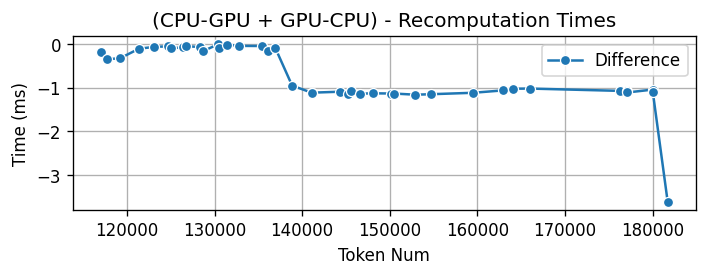

In [27]:
# 读取日志文件
with open('../server.log', 'r') as file:
    log_content = file.readlines()

# 初始化列表来存储提取的时间和token数量
cpu_to_gpu_times = []
gpu_to_cpu_times = []
recomputation_times = []
num_prefill_tokens = []
num_decode_tokens = []
token_sums = []
decode_times = []
decode_token_nums = []

# 正则表达式模式
cpu_to_gpu_pattern = re.compile(r'cpu to gpu: (\d+\.\d+) ms')
gpu_to_cpu_pattern = re.compile(r'gpu to cpu: (\d+\.\d+) ms')
recomputation_pattern = re.compile(r'prefill_time is (\d+\.\d+) ms, num_prefill_tokens is (\d+)')
# recomputation_pattern = re.compile(r'computation time: (\d+\.\d+) ms')
token_pattern = re.compile(r'num_blocks: (\d+), token_num: (\d+)')

decode_pattern = re.compile(r'decode_time is (\d+\.\d+) ms, num_decode_tokens is (\d+)')

# 遍历日志内容并提取时间
for line in log_content:
    cpu_to_gpu_match = cpu_to_gpu_pattern.search(line)
    gpu_to_cpu_match = gpu_to_cpu_pattern.search(line)
    recomputation_match = recomputation_pattern.search(line)
    token_match = token_pattern.search(line)
    decode_match = decode_pattern.search(line)

    
    if cpu_to_gpu_match:
        cpu_to_gpu_times.append(float(cpu_to_gpu_match.group(1)))
    if gpu_to_cpu_match:
        gpu_to_cpu_times.append(float(gpu_to_cpu_match.group(1)))
    if recomputation_match:
        recomputation_times.append(float(recomputation_match.group(1)))
    if token_match:
        token_sums.append(int(token_match.group(2)))
    if decode_match:
        decode_times.append(float(decode_match.group(1)))  
        decode_token_nums.append(int(decode_match.group(2)))

# 确保所有列表长度一致
min_length = min(len(cpu_to_gpu_times), len(gpu_to_cpu_times), len(recomputation_times), len(token_sums))
cpu_to_gpu_times = cpu_to_gpu_times[:min_length]
gpu_to_cpu_times = gpu_to_cpu_times[:min_length]
recomputation_times = recomputation_times[:min_length]
token_sums = token_sums[:min_length]

print(len(cpu_to_gpu_times), len(gpu_to_cpu_times), len(recomputation_times), len(token_sums), len(decode_times))

df = pd.DataFrame({
    'token_num': token_sums,
    'cpu2gpu': cpu_to_gpu_times,
    'gpu2cpu': gpu_to_cpu_times,
    'recomputation_time': recomputation_times,
})
df['swap_time'] = df['cpu2gpu'] + df['gpu2cpu']
df['Difference'] = (df['swap_time'] - df['recomputation_time'])
df = df.groupby("token_num").mean().reset_index()
df.sort_values(by='token_num',ascending=False,inplace=True)
df.to_csv("communation_recompute_cost_100.csv", mode='a', index=False, header=None)

decode_df = pd.DataFrame({
    'decode_time': decode_times,
    'decode_token_num': decode_token_nums,
})
decode_df = decode_df.groupby("decode_token_num").mean().reset_index()
decode_df.sort_values(by='decode_token_num',ascending=False,inplace=True)
decode_df.to_csv("decode_cost_100.csv", mode="a", index=False, header=None)
# 绘制曲线图
plt.figure(figsize=(6, 4), dpi=120)
plt.subplot(2, 1, 1)
sns.lineplot(data=df, x='token_num', y='Difference', label='Difference', marker='o')
# plt.plot(gpu_to_cpu_times, label='GPU to CPU Time', marker='o')
# plt.plot(df['Recomputation Time'], label='Recomputation Time', marker='o')
plt.xlabel('Token Num')
plt.ylabel('Time (ms)')
plt.title('(CPU-GPU + GPU-CPU) - Recomputation Times')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

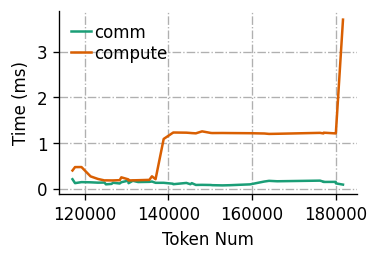

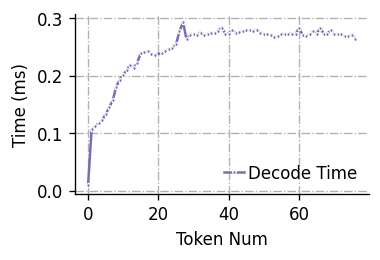

In [28]:
# fit the realtionship between token num and communication time/recomputation time
df = pd.read_csv("communation_recompute_cost_100.csv")
df.columns = ['token_num', 'cpu2gpu', 'gpu2cpu', 'recomputation_time', 'swap_time', 'Difference']
decode_df = pd.read_csv("decode_cost_100.csv")
decode_df.columns = ['decode_token_num', 'decode_time']
df = df.groupby("token_num").mean().reset_index()
df.to_csv("communation_recompute_cost_100.csv", mode='w', index=False, header=None)
decode_df = decode_df.groupby("decode_token_num").mean().reset_index()
decode_df.to_csv("decode_cost_100.csv", mode='w', index=False, header=None)
fig = plt.figure(figsize=(3, 2), dpi=120)
ax = plt.subplot(111)
sns.lineplot(data=df, x='token_num', y='swap_time', label='comm', color=plt.cm.Dark2(0))
sns.lineplot(data=df, x='token_num', y='recomputation_time', label='compute',  color=plt.cm.Dark2(1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Token Num')
ax.set_ylabel('Time (ms)')
ax.grid(True, linestyle='-.')
ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
plt.show()    

fig = plt.figure(figsize=(3, 2), dpi=120)
ax = plt.subplot(111)
sns.lineplot(data=decode_df, x='decode_token_num', y='decode_time', label='Decode Time', marker='p', markersize=3, color=plt.cm.Dark2(2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Token Num')
ax.set_ylabel('Time (ms)')
ax.grid(True, linestyle='-.')
ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
plt.show()    

In [26]:
import re
import pandas as pd

# 定义正则表达式模式
pattern = re.compile(
    r'decode_time is (?P<decode_time>\d+\.\d+) ms, decode_meta\.num_decode_tokens is (?P<num_decode_tokens>\d+), decode_meta\.seq_lens_tensor\.sum\(\) is (?P<seq_lens_sum>\d+)\n'
    r'attn time: (?P<attn_time>\d+\.\d+) ms\n'
    r'mlp time: (?P<mlp_time>\d+\.\d+) ms\n'
    r'real_decode time: (?P<real_decode_time>\d+\.\d+) ms',
    re.MULTILINE  # 允许匹配多行
)

# 读取日志文件
input_file = '../server.log'  # 替换为你的日志文件路径
output_file = 'parsed_log.csv'  # 输出CSV文件路径

# 初始化一个列表来存储解析结果
parsed_data = []

# 读取日志文件并解析
with open(input_file, 'r') as file:
    log_content = file.read()
    matches = pattern.finditer(log_content)
    for match in matches:
        # print(match.groupdict())  # 打印匹配结果
        parsed_data.append({
            'decode_time': float(match.group('real_decode_time')),
            'num_decode_tokens': int(match.group('num_decode_tokens')),
            'seq_lens_sum': int(match.group('seq_lens_sum')),
            'attn_time': float(match.group('attn_time')),
            'mlp_time': float(match.group('mlp_time'))
        })

# 将解析结果转换为 DataFrame
df = pd.DataFrame(parsed_data)
df = df.groupby(['num_decode_tokens', 'seq_lens_sum']).mean().reset_index()

# 去掉header column_names, 追加到csv文件
df.to_csv(output_file, mode='a', index=False, header=None)

KeyError: 'num_decode_tokens'

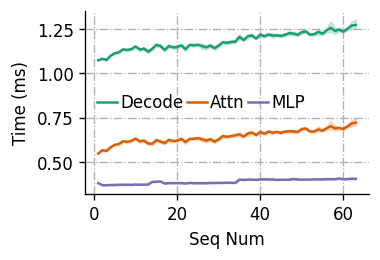

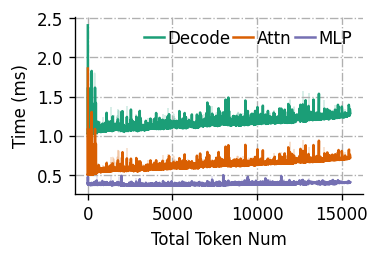

In [52]:
df = pd.read_csv("parsed_log.csv")
df.columns = ['num_decode_tokens','seq_lens_sum','decode_time','attn_time','mlp_time']

df = df.groupby(['num_decode_tokens', 'seq_lens_sum']).mean().reset_index()
df.to_csv("parsed_log_new.csv", mode='w', index=False, header=None)

fig = plt.figure(figsize=(3, 2), dpi=120)
ax = plt.subplot(111)
sns.lineplot(data=df, x='num_decode_tokens', y='decode_time', label='Decode', color=plt.cm.Dark2(0))
sns.lineplot(data=df, x='num_decode_tokens', y='attn_time', label='Attn', color=plt.cm.Dark2(1))
sns.lineplot(data=df, x='num_decode_tokens', y='mlp_time', label='MLP', color=plt.cm.Dark2(2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Seq Num')
ax.set_ylabel('Time (ms)')
ax.grid(True, linestyle='-.')
ax.legend(loc='best', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
plt.show()

fig = plt.figure(figsize=(3, 2), dpi=120)
ax = plt.subplot(111)
sns.lineplot(data=df, x='seq_lens_sum', y='decode_time', label='Decode',  color=plt.cm.Dark2(0))
sns.lineplot(data=df, x='seq_lens_sum', y='attn_time', label='Attn',  color=plt.cm.Dark2(1))
sns.lineplot(data=df, x='seq_lens_sum', y='mlp_time', label='MLP',  color=plt.cm.Dark2(2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Total Token Num')
ax.set_ylabel('Time (ms)')
ax.grid(True, linestyle='-.')
ax.legend(loc='best', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
plt.show()
 